#  Digital Addiction

This project explores how screen time habits relate to sleep, stress, and digital addiction. The dataset includes user information such as age, gender, daily screen time, social media use, sleep hours, stress level, and addiction status.

The goal is to clean the data, explore patterns, and create polished visuals that communicate the main findings clearly.

In [123]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("../Data/smartphone_addiction.csv")
df_original = pd.read_csv("../Data/smartphone_addiction.csv",
    keep_default_na=False
)

df = df_original.copy()

In [124]:
df.head()

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,None,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,None,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1


In [125]:
df.tail()

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
7495,TXN07496,U07496,26,Other,9.85,1.75,3.13,3.49,5.81,249,122,11.99,Low,Yes,Moderate,1
7496,TXN07497,U07497,35,Male,5.67,2.33,2.76,5.90,8.47,197,56,7.08,Low,No,None,0
7497,TXN07498,U07498,22,Female,9.99,3.61,1.09,1.16,8.17,207,24,12.84,Medium,Yes,Severe,1
7498,TXN07499,U07499,23,Male,8.74,1.59,0.07,4.64,6.19,134,62,10.52,High,Yes,Severe,1
7499,TXN07500,U07500,27,Female,10.04,5.40,0.73,5.45,5.58,215,38,12.17,Low,Yes,Severe,1


In [126]:
df.shape


(7500, 16)

In [127]:
df.columns

Index(['transaction_id', 'user_id', 'age', 'gender', 'daily_screen_time_hours',
       'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours',
       'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time',
       'stress_level', 'academic_work_impact', 'addiction_level',
       'addicted_label'],
      dtype='str')

In [128]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   transaction_id           7500 non-null   str    
 1   user_id                  7500 non-null   str    
 2   age                      7500 non-null   int64  
 3   gender                   7500 non-null   str    
 4   daily_screen_time_hours  7500 non-null   float64
 5   social_media_hours       7500 non-null   float64
 6   gaming_hours             7500 non-null   float64
 7   work_study_hours         7500 non-null   float64
 8   sleep_hours              7500 non-null   float64
 9   notifications_per_day    7500 non-null   int64  
 10  app_opens_per_day        7500 non-null   int64  
 11  weekend_screen_time      7500 non-null   float64
 12  stress_level             7500 non-null   str    
 13  academic_work_impact     7500 non-null   str    
 14  addiction_level          7500 non-n

In [129]:
df.dtypes

transaction_id                 str
user_id                        str
age                          int64
gender                         str
daily_screen_time_hours    float64
social_media_hours         float64
gaming_hours               float64
work_study_hours           float64
sleep_hours                float64
notifications_per_day        int64
app_opens_per_day            int64
weekend_screen_time        float64
stress_level                   str
academic_work_impact           str
addiction_level                str
addicted_label               int64
dtype: object

In [130]:
df.describe()


,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,addicted_label
count,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000
mean,26.568800,7.499912,3.273484,2.014183,3.242420,6.737561,134.257333,97.832400,9.243827,0.707733
std,5.197108,2.609188,1.585342,1.146039,1.600765,1.283605,66.586883,48.423349,2.718281,0.454835
min,18.000000,3.000000,0.500000,0.000000,0.500000,4.500000,20.000000,15.000000,3.580000,0.000000
25%,22.000000,5.220000,1.910000,1.020000,1.850000,5.630000,76.000000,55.000000,6.960000,0.000000
50%,27.000000,7.525000,3.270000,2.040000,3.230000,6.720000,134.000000,98.000000,9.260000,1.000000
75%,31.000000,9.810000,4.630000,2.990000,4.640000,7.840000,191.000000,140.000000,11.540000,1.000000
max,35.000000,12.000000,6.000000,4.000000,6.000000,9.000000,250.000000,180.000000,14.880000,1.000000


In the previous commands I explored the overall data and observed the columns and size of the dataset. 

In [131]:
df["age"].describe()

count    7500.000000
mean       26.568800
std         5.197108
min        18.000000
25%        22.000000
50%        27.000000
75%        31.000000
max        35.000000
Name: age, dtype: float64

In [132]:
df["gender"].value_counts()

gender
Male      2553
Other     2486
Female    2461
Name: count, dtype: int64

In [133]:
df.columns

Index(['transaction_id', 'user_id', 'age', 'gender', 'daily_screen_time_hours',
       'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours',
       'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time',
       'stress_level', 'academic_work_impact', 'addiction_level',
       'addicted_label'],
      dtype='str')

Value Counts for Categorical Columns

In [134]:
df['addiction_level'].value_counts


<bound method IndexOpsMixin.value_counts of 0           None
1           None
2           Mild
3       Moderate
4         Severe
          ...   
7495    Moderate
7496        None
7497      Severe
7498      Severe
7499      Severe
Name: addiction_level, Length: 7500, dtype: str>

In [135]:

df["stress_level"].value_counts()

stress_level
High      2560
Low       2503
Medium    2437
Name: count, dtype: int64

The distribution of the stress levels are not varied 

In [136]:
df["addiction_level"].value_counts()

addiction_level
Moderate    2874
Severe      2434
Mild        1373
None         819
Name: count, dtype: int64

In [137]:
df["academic_work_impact"].value_counts()

academic_work_impact
No     3753
Yes    3747
Name: count, dtype: int64

Missing Values

In [138]:
df.isna().sum()

transaction_id             0
user_id                    0
age                        0
gender                     0
daily_screen_time_hours    0
social_media_hours         0
gaming_hours               0
work_study_hours           0
sleep_hours                0
notifications_per_day      0
app_opens_per_day          0
weekend_screen_time        0
stress_level               0
academic_work_impact       0
addiction_level            0
addicted_label             0
dtype: int64

In [139]:
df[df["addiction_level"].isna()]

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label


It seems that the addition level from the csv is from none, moderate, and to severe.  I need to change the scale from 1 to 3 so I am able to include that column. 

In [140]:
addiction_scale = {
    'None': 0,
    'Mild': 1,
    'Moderate': 2,
    'Severe': 3
}

df['addiction_level_numeric'] = df['addiction_level'].map(addiction_scale)
df[['addiction_level', 'addiction_level_numeric']].head()

,addiction_level,addiction_level_numeric
0,None,0
1,None,0
2,Mild,1
3,Moderate,2
4,Severe,3


I changed the data to numeric so it is easier to compare and manage

Checking for Duplicates: 

In [141]:
df.duplicated().sum()

np.int64(0)

There does not seem to be any duplicates

In [142]:
df[df['age']<25]

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label,addiction_level_numeric
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,None,0,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,None,0,0
8,TXN00009,U00009,21,Other,4.38,1.38,2.72,3.78,6.23,172,134,6.20,High,Yes,None,0,0
14,TXN00015,U00015,19,Male,10.74,0.89,0.95,4.18,5.46,53,161,12.68,Low,No,Severe,1,3
15,TXN00016,U00016,21,Male,3.87,2.87,1.69,3.07,7.78,192,180,4.62,Medium,No,None,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7490,TXN07491,U07491,21,Female,3.08,5.68,3.57,5.53,4.89,41,104,5.82,High,No,Severe,1,3
7493,TXN07494,U07494,19,Female,10.41,3.32,3.88,5.58,6.77,122,96,10.93,Low,Yes,Severe,1,3
7494,TXN07495,U07495,23,Other,6.65,4.56,1.31,5.09,5.71,78,77,7.43,Medium,No,Severe,1,3
7497,TXN07498,U07498,22,Female,9.99,3.61,1.09,1.16,8.17,207,24,12.84,Medium,Yes,Severe,1,3


In [143]:
df[df['age']>39]

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label,addiction_level_numeric


For this section I filtered the data to see the range of ages as well understand how the filtering works. I realized that there would be a cut off in age because older adults are not typically in education therefore their academic levels would not exist. 

In [144]:
df[df["stress_level"] == "High"]

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label,addiction_level_numeric
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0,1
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1,2
8,TXN00009,U00009,21,Other,4.38,1.38,2.72,3.78,6.23,172,134,6.20,High,Yes,None,0,0
11,TXN00012,U00012,27,Other,5.16,1.82,2.27,0.93,7.79,228,32,8.10,High,Yes,None,0,0
13,TXN00014,U00014,32,Male,4.09,1.74,1.35,3.74,5.54,76,16,4.77,High,Yes,None,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7488,TXN07489,U07489,19,Other,6.73,1.46,1.24,4.28,7.00,204,124,7.72,High,Yes,Mild,0,1
7489,TXN07490,U07490,19,Other,9.46,2.89,0.87,3.04,4.75,137,63,12.37,High,No,Moderate,1,2
7490,TXN07491,U07491,21,Female,3.08,5.68,3.57,5.53,4.89,41,104,5.82,High,No,Severe,1,3
7492,TXN07493,U07493,27,Female,3.29,1.82,0.41,5.94,6.86,29,117,4.03,High,No,Mild,0,1


In [145]:
df.drop(columns=["user_id","transaction_id", "gaming_hours"])

,age,gender,daily_screen_time_hours,social_media_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label,addiction_level_numeric
0,21,Male,3.23,2.01,4.55,7.55,248,154,3.95,Medium,Yes,None,0,0
1,24,Other,5.09,3.81,4.44,7.66,127,71,6.71,Medium,Yes,None,0,0
2,31,Other,6.06,1.36,2.35,4.92,44,106,8.68,High,No,Mild,0,1
3,32,Other,7.83,5.85,3.54,8.23,178,107,9.77,High,Yes,Moderate,1,2
4,25,Male,9.96,5.92,5.27,6.21,136,177,12.55,Low,No,Severe,1,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7495,26,Other,9.85,1.75,3.49,5.81,249,122,11.99,Low,Yes,Moderate,1,2
7496,35,Male,5.67,2.33,5.90,8.47,197,56,7.08,Low,No,None,0,0
7497,22,Female,9.99,3.61,1.16,8.17,207,24,12.84,Medium,Yes,Severe,1,3
7498,23,Male,8.74,1.59,4.64,6.19,134,62,10.52,High,Yes,Severe,1,3


I decided to drop the transition and user_id because they did not serve a purpose.  Also since the analysis is on smartphone usage I decided to remove gaming hours.

Clean Data:

In [146]:
df = df.drop_duplicates()

In [147]:
df = df.dropna()

In [148]:
df['age'] = df['age'].astype(int)
df['addicted_label'] = df['addicted_label'].astype(int)

In [149]:
df['addicted_status'] = df['addicted_label'].map({
    0: 'Not Addicted',
    1: 'Addicted'
})

For this I needed to change the labels to 1s and zeros that way I would be able to quantify them. I also removed duplicate rows and dropped missing values so the analysis would be based on complete records. I finally converted key columns into the correct data types.

In [150]:
df.groupby('addicted_status')[['daily_screen_time_hours', 'sleep_hours']].mean()

,daily_screen_time_hours,sleep_hours
addicted_status,,
Addicted,8.467502,6.766839
Not Addicted,5.156861,6.666665


In [155]:
df['addiction_level'].value_counts(dropna=False)

addiction_level
Moderate    2874
Severe      2434
Mild        1373
None         819
Name: count, dtype: int64

I was running into an error here with no values presenting for none therefore I was checking before using the data for my charts. 

Visualizations

Going over the charts I am having difficulty trying to find the right charts to demonstrate my data.  I need to go over the three main questions I want to answer.  

1. Does higher screen time relate to higher addiction levels? 

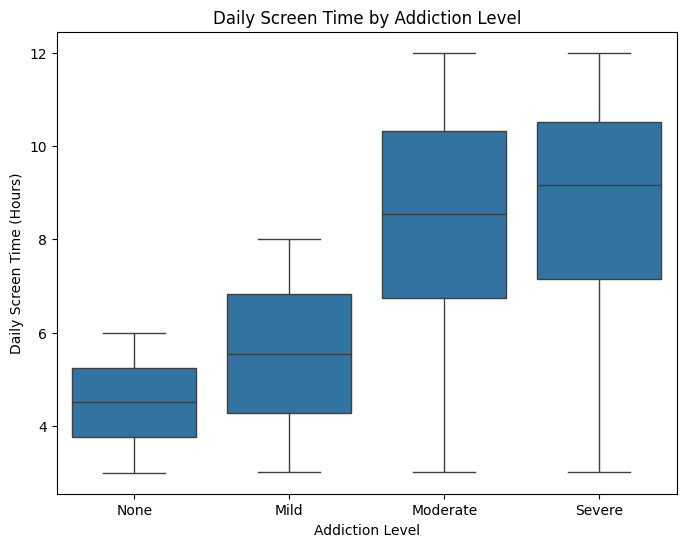

In [156]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x='addiction_level',
    y='daily_screen_time_hours',
    order=['None', 'Mild', 'Moderate', 'Severe']
)

plt.title('Daily Screen Time by Addiction Level')

plt.xlabel('Addiction Level')
plt.ylabel('Daily Screen Time (Hours)')

plt.show()


### Daily Screen Time by Addiction Level

For this chart I wanted to explore whether higher addiction levels are associated with higher daily screen time.

A boxplot was chosen because it clearly shows the spread, median, and variation in screen time across each addiction category. The addiction levels were ordered from `None` to `Severe` to show progression clearly.

I used clear labels and a simple design to keep the chart easy to read and avoid misleading comparisons.  From this data we can observe how increasing number of screen time is associated with higher levels of stress rating more moderate to severe. 

2. Is screen addiction associated with negative academic impact?

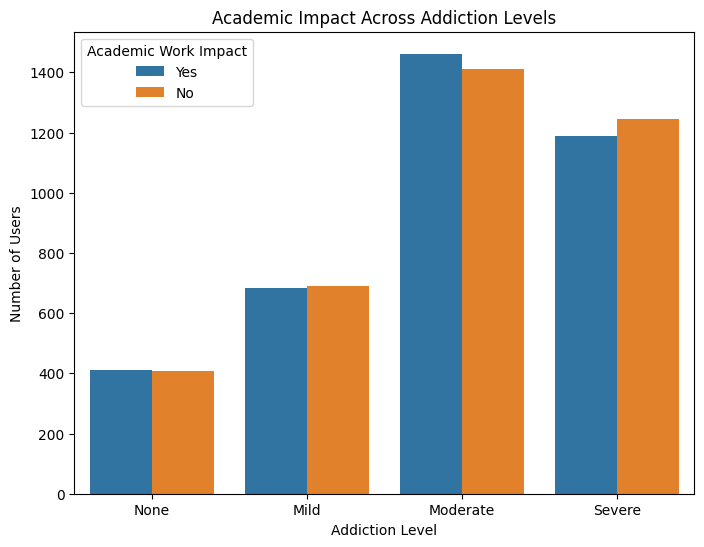

In [157]:
plt.figure(figsize=(8,6))

sns.countplot(
    data=df,
    x='addiction_level',
    hue='academic_work_impact',
    order=['None', 'Mild', 'Moderate', 'Severe']
)

plt.title('Academic Impact Across Addiction Levels')

plt.xlabel('Addiction Level')
plt.ylabel('Number of Users')

plt.legend(title='Academic Work Impact')

plt.show()

### Academic Impact Across Addiction Levels
The data is strange for this chart as the number of users for each category of severity are similar.This chart suggests that users in the moderate and severe addiction categories more frequently reported academic impact compared to users with lower addiction levels.

A grouped bar chart was chosen because it clearly compares categorical responses across each addiction category. Clear labels and consistent scaling were used to keep the comparison easy to interpret. Finally blue and orange was selected because the colors are contrasting. 

3. “Do users who receive more notifications spend more time on their devices?”

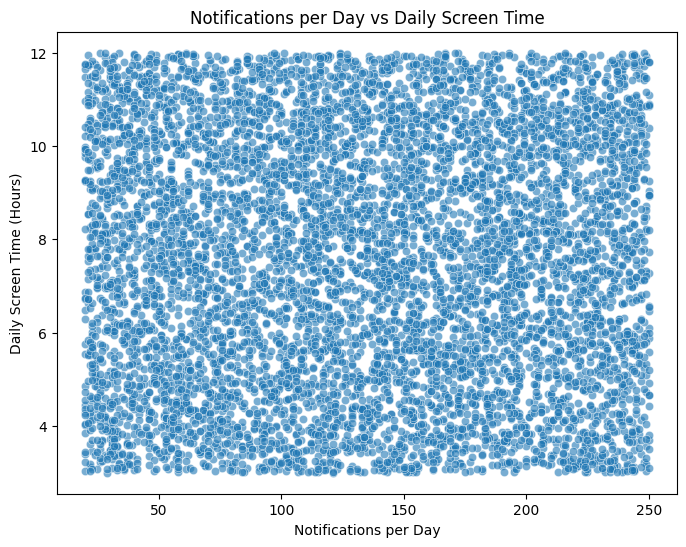

In [159]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='notifications_per_day',
    y='daily_screen_time_hours',
    alpha=0.6
)

plt.title('Notifications per Day vs Daily Screen Time')

plt.xlabel('Notifications per Day')
plt.ylabel('Daily Screen Time (Hours)')

plt.show()

In this chart there was no correlation presented with the number of notifications and screen time therefore.   I need to explore this further as there may have been a better comparison to be explored or if my data does have something wrong with it.  However, notifications and screen time do not appear meaningfully related from the chart. 

“What is the gender distribution of users classified as addicted?”

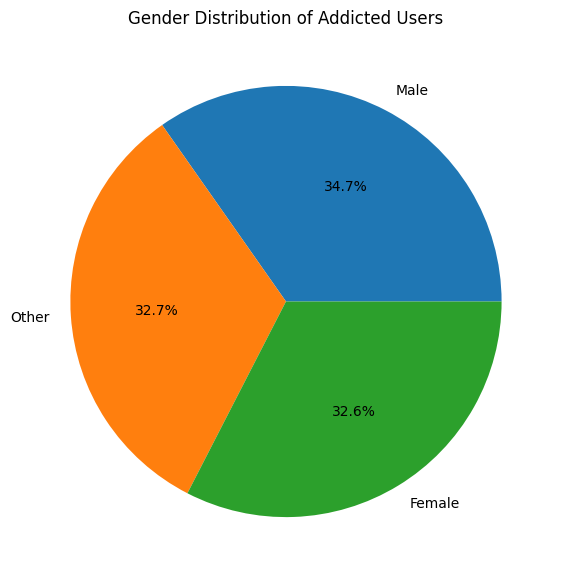

In [161]:
addicted_users = df[df['addicted_label'] == 1]

gender_counts = addicted_users['gender'].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    gender_counts.values,
    labels=gender_counts.index,
    autopct='%1.1f%%'
)

plt.title('Gender Distribution of Addicted Users')

plt.show()

### Gender Distribution of Addicted Users

I finally wanted to explore the distribution of addiction levels across gender groups. A pie chart was chosen because it clearly shows the proportion each gender contributes to the addicted user population.

At this stage of the analysis, the dataset also appeared highly uniform, with relatively low variance across several variables. This made some patterns appear less natural and suggests the data may be simplified or artificially generated rather than fully representative of real-world behaviour.